# 03 — Statistical Testing, Effect Size & Practical Significance

This is where the decision gets made. The notebook works through, in order:

1. Choosing and justifying the test
2. Primary and secondary metric results with confidence intervals
3. Statistical power — what this experiment could and could not have detected
4. Practical significance and quantified business impact
5. CUPED — evaluated honestly rather than performed for show
6. Segment analysis, with the post-treatment bias problem handled explicitly
7. Falsification tests that probe whether the headline effect is real
8. Threats to validity

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import experiment_analysis as ea

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

DATA_PATH = os.path.join("..", "data", "cookie_cats.csv")
FIG_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

CONTROL, TREATMENT = "gate_30", "gate_40"

# Chart theme. Two-series categorical palette, validated for colour-vision
# deficiency separation (worst-pair CVD dE 24.7, normal-vision dE 33.6).
C_CONTROL, C_TREATMENT = "#2a78d6", "#eb6834"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CRITICAL = "#d03b3b"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.bbox": "tight",
})

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from {DATA_PATH}")

Loaded 90,189 rows x 5 columns from ..\data\cookie_cats.csv


## 3.1 Choosing the test

**The test: a two-sample z-test for proportions.**

**What it does.** It asks how likely we would be to observe a gap this large between two
groups' retention rates if the two groups' true rates were actually identical. It does
this by dividing the observed difference by its standard error and comparing the result
to a normal distribution.

**Why it is the right choice here.** Four conditions have to hold, and all four do:

| Requirement | Status in this experiment |
|---|---|
| Outcome is binary per unit | `retention_7` is True/False per player |
| Observations independent | One row per player, verified in notebook 01; no user in both arms |
| Large samples — the normal approximation needs $np$ and $n(1-p)$ comfortably above ~10 | Smallest cell is 7-day retained in control: $44{,}700 \times 0.19 \approx 8{,}502$. Orders of magnitude above the bar. |
| Randomized assignment | Yes; SRM check passed at the conventional p < 0.001 threshold |

**Why not something else.**

- A **chi-square test of independence** on the 2x2 table is mathematically equivalent to
  the two-sided z-test here ($\chi^2 = z^2$). The z-test is preferred because it yields a
  signed effect and a confidence interval on the difference, which a chi-square does not.
- **Fisher's exact test** is for small samples. With 90,189 rows it is unnecessary and
  computationally wasteful.
- A **t-test** on the 0/1 column gives nearly identical answers at this sample size, but
  the proportion test is the purpose-built tool and carries the right standard error.

**What the p-value will and will not mean.** It is the probability of seeing a difference at
least this extreme *if the gate change truly did nothing*. It is **not** the probability
that the gate change did nothing, and it says nothing at all about whether the effect is
big enough to care about. That second question is handled separately in section 3.4.

## 3.2 Primary metric — 7-day retention

In [2]:
def analyse_metric(frame, metric, label):
    """Run the full comparison for one binary metric and return a tidy dict."""
    rates = ea.calculate_conversion_rate(frame, metric, "version")
    c, t = rates.loc[CONTROL], rates.loc[TREATMENT]

    lift = ea.calculate_lift(c["rate"], t["rate"])
    test = ea.proportion_test(int(c["successes"]), int(c["n"]),
                              int(t["successes"]), int(t["n"]))
    dci = ea.diff_confidence_interval(int(c["successes"]), int(c["n"]),
                                      int(t["successes"]), int(t["n"]))
    ci_c = ea.confidence_interval(int(c["successes"]), int(c["n"]))
    ci_t = ea.confidence_interval(int(t["successes"]), int(t["n"]))

    print(f"{'=' * 72}")
    print(f"{label}   ({metric})")
    print(f"{'=' * 72}")
    print(f"  Control   {CONTROL}:  {int(c['successes']):>6,} / {int(c['n']):>6,}  "
          f"= {c['rate']:.4%}   95% CI [{ci_c[0]:.4%}, {ci_c[1]:.4%}]")
    print(f"  Treatment {TREATMENT}:  {int(t['successes']):>6,} / {int(t['n']):>6,}  "
          f"= {t['rate']:.4%}   95% CI [{ci_t[0]:.4%}, {ci_t[1]:.4%}]")
    print()
    print(f"  Absolute difference   : {lift['absolute_diff_pp']:+.4f} percentage points")
    print(f"  Relative lift         : {lift['relative_lift_pct']:+.4f}%")
    print(f"  95% CI on difference  : [{dci['lower'] * 100:+.4f} pp, {dci['upper'] * 100:+.4f} pp]")
    print(f"  Standard error        : {dci['se'] * 100:.4f} pp")
    print()
    print(f"  z-statistic           : {test['z_statistic']:.4f}")
    print(f"  p-value (two-sided)   : {test['p_value']:.6f}")
    print(f"  Significant at 0.05   : {test['significant_at_0.05']}")
    print()

    return {"metric": metric, "label": label, **lift, **test,
            "ci_low": dci["lower"], "ci_high": dci["upper"], "se": dci["se"],
            "n_control": int(c["n"]), "n_treatment": int(t["n"])}


r7 = analyse_metric(df, "retention_7", "PRIMARY METRIC - 7-day retention")

PRIMARY METRIC - 7-day retention   (retention_7)
  Control   gate_30:   8,502 / 44,700  = 19.0201%   95% CI [18.6590%, 19.3866%]
  Treatment gate_40:   8,279 / 45,489  = 18.2000%   95% CI [17.8481%, 18.5573%]

  Absolute difference   : -0.8201 percentage points
  Relative lift         : -4.3119%
  95% CI on difference  : [-1.3282 pp, -0.3121 pp]
  Standard error        : 0.2592 pp

  z-statistic           : -3.1644
  p-value (two-sided)   : 0.001554
  Significant at 0.05   : True



### Reading the primary result in plain language

**Moving the gate from level 30 to level 40 reduced 7-day retention.**

Out of every 1,000 new players, about **190 came back a week later under the current
design (`gate_30`)**, versus about **182 under the proposed design (`gate_40`)** — roughly
**8 fewer returning players per 1,000**.

- The gap is **0.82 percentage points**, or a **4.3% relative decline** in 7-day retention.
- The **p-value is 0.0016**. If the gate change genuinely made no difference, we would see
  a gap this large only about **16 times in 10,000** experiments. That is strong evidence
  the difference is not a fluke.
- The **95% confidence interval on the difference runs from −1.33 pp to −0.31 pp**. This is
  the most important number in the notebook: *the entire interval sits below zero*. The
  data is consistent with the treatment being anywhere from slightly harmful to
  meaningfully harmful, and is **not** consistent with it being beneficial.

The direction is unambiguous. `gate_40` is worse than `gate_30` on the primary metric.

## 3.3 Secondary metrics

In [3]:
r1 = analyse_metric(df, "retention_1", "SECONDARY METRIC - 1-day retention")

SECONDARY METRIC - 1-day retention   (retention_1)
  Control   gate_30:  20,034 / 44,700  = 44.8188%   95% CI [44.3582%, 45.2802%]
  Treatment gate_40:  20,119 / 45,489  = 44.2283%   95% CI [43.7724%, 44.6851%]

  Absolute difference   : -0.5905 percentage points
  Relative lift         : -1.3176%
  95% CI on difference  : [-1.2392 pp, +0.0582 pp]
  Standard error        : 0.3310 pp

  z-statistic           : -1.7841
  p-value (two-sided)   : 0.074410
  Significant at 0.05   : False



### Reading the 1-day result — and what "not significant" does *not* mean

D1 retention is **0.59 pp lower** under `gate_40` (44.82% → 44.23%), a 1.3% relative
decline, with **p = 0.074**. By the conventional α = 0.05 bar, this is **not statistically
significant**.

> **The experiment had limited power to detect a D1 effect of the size observed (43% — see
> section 3.4). The absence of statistical significance must therefore NOT be interpreted as
> evidence that there is no effect on 1-day retention.**

The correct interpretation is *"we did not detect an effect"*, **not** *"there is no
effect"*. The confidence interval runs from **−1.24 pp to +0.06 pp** — it does cross zero,
but only barely, and the overwhelming bulk of it lies on the negative side. This result is
perfectly compatible with a real, modest harm to D1 retention that this experiment was
not powerful enough to resolve. Section 3.4 quantifies exactly that.

What it is *not* compatible with is a meaningful **improvement** in D1 retention: the upper
bound is +0.06 pp, which is indistinguishable from zero. So the secondary metric does not
rescue the treatment either — but nor does it convict it. Both metrics' point estimates move
the same direction; only the primary metric reaches statistical significance.

In [4]:
# Engagement is a skewed count, not a proportion, so the proportion test does not
# apply. Reported here for completeness using outlier-robust methods (see nb 02).
cap = df["sum_gamerounds"].quantile(0.99)
wins = df["sum_gamerounds"].clip(upper=cap)
cw, tw = wins[df.version == CONTROL], wins[df.version == TREATMENT]
welch = stats.ttest_ind(tw, cw, equal_var=False)
ci_lo, ci_hi = welch.confidence_interval(0.95)

print("SECONDARY METRIC - total game rounds (winsorized at p99)")
print(f"  Control   mean : {cw.mean():.3f}")
print(f"  Treatment mean : {tw.mean():.3f}")
print(f"  Difference     : {tw.mean() - cw.mean():+.3f} rounds")
print(f"  95% CI         : [{ci_lo:+.3f}, {ci_hi:+.3f}] rounds")
print(f"  Welch t-test   : t = {welch.statistic:.4f}, p = {welch.pvalue:.4f}")
print()
print("  -> No detectable difference in play volume between arms.")

SECONDARY METRIC - total game rounds (winsorized at p99)


  Control   mean : 49.136
  Treatment mean : 48.854
  Difference     : -0.282 rounds
  95% CI         : [-1.381, +0.817] rounds
  Welch t-test   : t = -0.5027, p = 0.6152

  -> No detectable difference in play volume between arms.


## 3.4 Statistical power — what this experiment could have detected

**What it does.** Power analysis asks: given these sample sizes, how large would an effect
have to be before we had a good chance of spotting it?

**Why it matters here.** It is the difference between "the treatment has no effect" and
"this experiment was too small to say." Reporting a null result without reporting power is
one of the most common errors in experiment analysis, because it silently converts
*ignorance* into *evidence of absence*.

In [5]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

power_calc = NormalIndPower()
n_c = int((df.version == CONTROL).sum())
n_t = int((df.version == TREATMENT).sum())
ratio = n_t / n_c

# Minimum detectable effect: the Cohen's h we have 80% power to detect, converted
# back into percentage points around each metric's observed baseline.
h_mde = power_calc.solve_power(effect_size=None, nobs1=n_c, alpha=0.05,
                               power=0.80, ratio=ratio, alternative="two-sided")

def h_to_pp(h, p_base):
    """Convert a Cohen's h effect size back to an absolute difference in proportions."""
    return np.sin(np.arcsin(np.sqrt(p_base)) + h / 2) ** 2 - p_base

print(f"Sample sizes: control {n_c:,}  treatment {n_t:,}\n")
print(f"{'metric':<14}{'baseline':>10}{'MDE (pp)':>11}{'MDE (rel)':>11}"
      f"{'observed (pp)':>15}{'power':>9}")
print("-" * 70)

for metric, res in [("retention_7", r7), ("retention_1", r1)]:
    p_base = df.loc[df.version == CONTROL, metric].mean()
    p_treat = df.loc[df.version == TREATMENT, metric].mean()
    mde_pp = h_to_pp(h_mde, p_base) * 100
    obs_h = proportion_effectsize(p_treat, p_base)
    achieved = power_calc.solve_power(effect_size=abs(obs_h), nobs1=n_c, alpha=0.05,
                                      ratio=ratio, alternative="two-sided")
    print(f"{metric:<14}{p_base:>9.2%}{mde_pp:>11.3f}{mde_pp / (p_base * 100):>10.1%}"
          f"{res['absolute_diff_pp']:>+15.3f}{achieved:>9.1%}")

Sample sizes: control 44,700  treatment 45,489

metric          baseline   MDE (pp)  MDE (rel)  observed (pp)    power
----------------------------------------------------------------------
retention_7      19.02%      0.738      3.9%         -0.820    88.6%


retention_1      44.82%      0.929      2.1%         -0.591    43.0%


**Result, and it changes how we read the two metrics differently.**

- **For 7-day retention**, the experiment had **89% power** against the effect actually
  observed. That is a well-powered test: the significant result is not a lucky draw from
  an underpowered design, and the MDE (0.74 pp) sits just below the observed effect
  (0.82 pp). This experiment was correctly sized for the question it answered.

- **For 1-day retention**, the experiment had only **43% power** against the observed
  effect. This is the crucial caveat on the D1 null, and it is worth stating in full:

> **The experiment had limited power (43%) to detect a D1 effect of the size observed, so the
> absence of statistical significance should NOT be interpreted as evidence of no effect on
> 1-day retention.**

With 43% power we would fail to detect a genuine effect of that size **more often than we
would detect it** — worse than a coin flip. The non-significant D1 result is therefore a
statement about the experiment's resolution, not about the world. Reading it as "gate_40 is
safe for D1" would be a mistake.

This asymmetry is exactly why the primary metric is designated in advance. D7 is the
metric this experiment can actually speak to.

**Why report power at all, rather than just the p-value?** Because a null result without a
power figure silently converts *ignorance* into *evidence of absence*. Reporting 43% is what
makes the D1 result honestly interpretable — and it is the difference between "the treatment
does not hurt D1" (unsupported) and "we could not tell whether it hurts D1" (true).

## 3.5 Practical significance — is 0.82 pp worth acting on?

Statistical significance says the effect is probably real. It says nothing about whether
it is worth a product decision. With 90,189 users, we have enough power to detect effects
far too small to matter commercially — so the two questions must be separated.

**All figures below rest on clearly labelled assumptions and should be read as
order-of-magnitude, not as a forecast.**

In [6]:
# --- ASSUMPTIONS (stated explicitly; none of these come from the dataset) ---
ASSUMED_NEW_PLAYERS = 1_000_000   # hypothetical new-player cohort, for scaling only
# The dataset contains NO revenue, ARPU, or LTV data. We therefore do NOT convert
# retained players into money. Any such figure would be invented.

diff = r7["absolute_diff"]
lo, hi = r7["ci_low"], r7["ci_high"]

print("ASSUMPTION: a cohort of 1,000,000 new players, retention rates as measured.")
print("ASSUMPTION: the experiment population is representative of future new players.")
print()
print("Projected 7-day-retained players under each design:")
print(f"  gate_30 (keep current): {r7['control_rate'] * ASSUMED_NEW_PLAYERS:>10,.0f}")
print(f"  gate_40 (move gate)   : {r7['treatment_rate'] * ASSUMED_NEW_PLAYERS:>10,.0f}")
print()
print(f"Net change from moving the gate: {diff * ASSUMED_NEW_PLAYERS:>+10,.0f} players")
print(f"  95% CI: [{lo * ASSUMED_NEW_PLAYERS:+,.0f}, {hi * ASSUMED_NEW_PLAYERS:+,.0f}] players")
print()
print("Per 1,000 new players:")
print(f"  {diff * 1000:+.2f} retained players "
      f"(95% CI [{lo * 1000:+.2f}, {hi * 1000:+.2f}])")

ASSUMPTION: a cohort of 1,000,000 new players, retention rates as measured.
ASSUMPTION: the experiment population is representative of future new players.

Projected 7-day-retained players under each design:
  gate_30 (keep current):    190,201
  gate_40 (move gate)   :    182,000

Net change from moving the gate:     -8,201 players
  95% CI: [-13,282, -3,121] players

Per 1,000 new players:
  -8.20 retained players (95% CI [-13.28, -3.12])


### Business interpretation

Under the stated assumptions, for every **1,000,000 new players**, moving the gate to
level 40 would be expected to produce roughly **8,200 fewer players still active at day 7**,
with a plausible range of **3,100 to 13,300 fewer**.

**Is that practically significant? Yes — and the reasoning is about asymmetry, not size.**

A 4.3% relative decline in 7-day retention is a meaningful number in mobile gaming, where
retention compounds: fewer D7 players means fewer D30 players, fewer eventual payers, and
a smaller base for word-of-mouth. But the decisive argument is simpler:

> **The change has no measured upside.** Retention is down, engagement is flat, and the
> confidence interval on the primary metric lies entirely below zero. There is no metric
> in this dataset on which `gate_40` wins.

Even if one argued the 0.82 pp effect is commercially marginal, the decision calculus is
unchanged: we would be accepting a measurable, statistically significant cost in exchange
for **no demonstrated benefit**. That is not a trade worth making.

**What we deliberately do not claim.** The dataset has no revenue column, no ARPU, and no
LTV. We therefore do not translate retained players into dollars. Doing so would require
inventing a monetization assumption, and a fabricated revenue figure would be the least
defensible number in the analysis. If the business supplies an ARPU figure, the conversion
is one multiplication away — but that number must come from the business, not from us.

**One real caveat on the upside side.** A gate is a monetization mechanic. It is *possible*
that `gate_40` reduces retention while increasing revenue per player (by letting players
get more invested before hitting friction). This dataset cannot test that, and it is the
single most important open question the analysis leaves behind.

## 3.6 CUPED — evaluated, and deliberately not applied

**What CUPED is.** CUPED (Controlled-experiment Using Pre-Experiment Data) is a variance
reduction technique. It uses a covariate measured **before** the experiment started to
explain away some of the natural variation between users, leaving a cleaner signal. The
adjusted metric is:

$$Y_{\text{CUPED}} = Y - \theta\,(X - \bar{X}), \qquad \theta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

where $Y$ is the outcome and $X$ is the pre-experiment covariate. Because $X$ is measured
before randomization, it cannot be affected by the treatment, so subtracting it removes
noise without introducing bias. Variance reduction is roughly $\rho^2$, the squared
correlation between $X$ and $Y$ — a covariate correlated 0.5 with the outcome cuts
variance by ~25%, which is equivalent to a free increase in sample size.

**The non-negotiable requirement: $X$ must be strictly pre-treatment.**

In [7]:
print("Every column in this dataset, classified by timing:\n")
timing = {
    "userid":         ("pre-treatment",  "identifier only - carries no behavioural signal"),
    "version":        ("assignment",     "this IS the treatment"),
    "sum_gamerounds": ("POST-treatment", "rounds played during/after the experiment"),
    "retention_1":    ("POST-treatment", "outcome"),
    "retention_7":    ("POST-treatment", "outcome"),
}
for col in df.columns:
    when, note = timing[col]
    print(f"  {col:<16} {when:<15} {note}")

print()
pre_treatment_covariates = [
    c for c, (when, _) in timing.items()
    if when == "pre-treatment" and c != "userid"
]
print(f"Usable pre-experiment covariates: {pre_treatment_covariates} -> none")

Every column in this dataset, classified by timing:

  userid           pre-treatment   identifier only - carries no behavioural signal
  version          assignment      this IS the treatment
  sum_gamerounds   POST-treatment  rounds played during/after the experiment
  retention_1      POST-treatment  outcome
  retention_7      POST-treatment  outcome

Usable pre-experiment covariates: [] -> none


### Conclusion on CUPED

> **CUPED was evaluated but not applied because the available dataset does not contain an
> appropriate pre-experiment covariate.**

Every behavioural column — `sum_gamerounds`, `retention_1`, `retention_7` — is measured
**after** randomization. `userid` is pre-treatment but is an arbitrary identifier with no
behavioural content.

**Why we did not force it.** The tempting move is to use `sum_gamerounds` as the covariate,
since it correlates strongly with retention (r = 0.52). **This would be actively wrong**,
and not merely imperfect. `sum_gamerounds` is an outcome of the treatment: the gate's
whole purpose is to influence how far players progress, and notebook 02 showed control
players visibly stalling at their gate. Adjusting the outcome by a treatment-affected
variable **biases the estimated treatment effect** — it partials out part of the very
effect we are trying to measure. That is a textbook post-treatment-adjustment error, and
it would produce a more precise-looking estimate of the wrong quantity. A tighter
confidence interval around a biased point estimate is worse than an honest wide one.

### How CUPED *would* be applied, given the right data

In a production experimentation platform, this experiment would be instrumented so CUPED
were available:

1. **Choose the pre-period.** Take a fixed window immediately before randomization — commonly
   1 to 4 weeks. For a game testing a gate change on *existing* players, this is
   straightforward.
2. **Pick covariates correlated with the outcome.** For a retention metric the natural
   candidates are pre-period sessions per user, pre-period days active, pre-period rounds
   played, and prior-period retention. Prior-period value of *the same metric* is usually
   the strongest single choice.
3. **Estimate θ on the pooled data** (both arms together) as $\text{Cov}(Y, X) / \text{Var}(X)$,
   then compute the adjusted metric and run the identical z-test on it.
4. **Verify the covariate is balanced across arms** before trusting the adjustment.

**The catch specific to this experiment.** Cookie Cats randomizes players **at install**.
A brand-new player has, by construction, no pre-experiment history — there is no
pre-period to measure. So CUPED is not merely unavailable in this dataset; it is largely
**inapplicable to new-user experiments in general**. The realistic variance-reduction
options for an install-time test are different tools: stratified randomization on
install-time attributes that *are* known (country, platform, device tier, acquisition
channel), or regression adjustment on those same attributes. None of those columns are
present here either, but they would be obtainable in a production setting.

## 3.7 Segment analysis — exploratory, with the bias stated up front

**Read this section as hypothesis-generating, not as evidence.**

The only variable rich enough to segment on is `sum_gamerounds`, and it is a
**post-treatment variable**. This creates a specific, well-understood problem:

> **Post-treatment conditioning bias.** Splitting players by engagement means splitting
> them on something the treatment itself influences. A `gate_30` player who quit at the
> level-30 wall lands in "medium engagement"; the same player under `gate_40` might have
> sailed to "high engagement". The segments therefore contain **different kinds of people
> in each arm**, so a within-segment comparison is no longer a randomized comparison. The
> groups being compared are no longer exchangeable.

This is a **collider-stratification** problem, and no amount of sample size fixes it. The
only unbiased causal estimate available is the overall intent-to-treat result from
section 3.2.

We run the segmentation anyway — because heterogeneity is genuinely worth knowing about
for designing the *next* experiment — but nothing here may be used to justify the
decision.

In [8]:
seg_df = df.copy()
seg_df["engagement_segment"] = pd.qcut(
    seg_df["sum_gamerounds"].rank(method="first"), q=3,
    labels=["Low", "Medium", "High"]
)

seg7 = ea.segment_analysis(seg_df, "retention_7", "version", "engagement_segment",
                           CONTROL, TREATMENT)
print("EXPLORATORY - 7-day retention by engagement segment (post-treatment split)")
print(seg7.to_string(index=False))

EXPLORATORY - 7-day retention by engagement segment (post-treatment split)


segment  n_control  n_treatment  control_rate  treatment_rate  absolute_diff_pp  relative_lift_pct  p_value  significant_at_0.05
    Low      14734        15329      0.014524        0.015526          0.100190           6.898110 0.475468                False
 Medium      14943        15120      0.081309        0.074868         -0.644125          -7.921941 0.037396                 True
   High      15023        15040      0.470811        0.459375         -1.143642          -2.429088 0.046836                 True


### The multiple-comparisons problem

Three segments means three tests. Each test carries its own 5% false-positive rate, so the
chance of at least one spurious "significant" result is roughly
$1 - 0.95^3 \approx 14\%$, not 5%. Running segment tests and reporting the ones that
come back significant — without correction — is the mechanism behind most
irreproducible subgroup findings.

We correct for this using three standard methods:

- **Bonferroni** — multiply each p-value by the number of tests. Simple and conservative.
- **Holm** — a stepwise version of Bonferroni; uniformly more powerful, same guarantee.
- **Benjamini-Hochberg (FDR)** — controls the *expected proportion* of false discoveries
  rather than the probability of any; the least conservative of the three.

In [9]:
from statsmodels.stats.multitest import multipletests

raw_p = seg7["p_value"].values
print(f"Raw p-values: {np.round(raw_p, 4)}")
print(f"Naive family-wise error rate with 3 uncorrected tests: "
      f"{1 - 0.95 ** len(raw_p):.1%}\n")

adjusted = pd.DataFrame({"segment": seg7["segment"], "raw_p": raw_p})
for method in ["bonferroni", "holm", "fdr_bh"]:
    reject, p_adj, _, _ = multipletests(raw_p, alpha=0.05, method=method)
    adjusted[f"{method}_p"] = p_adj
    adjusted[f"{method}_sig"] = reject

print(adjusted.to_string(index=False))
print()
print(f"Segments significant after ANY correction method: "
      f"{int(adjusted[[c for c in adjusted.columns if c.endswith('_sig')]].values.sum())}")

Raw p-values: [0.4755 0.0374 0.0468]
Naive family-wise error rate with 3 uncorrected tests: 14.3%



segment    raw_p  bonferroni_p  bonferroni_sig   holm_p  holm_sig  fdr_bh_p  fdr_bh_sig
    Low 0.475468      1.000000           False 0.475468     False  0.475468       False
 Medium 0.037396      0.112187           False 0.112187     False  0.070255       False
   High 0.046836      0.140509           False 0.112187     False  0.070255       False

Segments significant after ANY correction method: 0


**Result: no segment survives correction.**

The Medium (p = 0.037) and High (p = 0.047) segments look significant on raw p-values.
After correcting for the three comparisons, **none of them is** — Bonferroni-adjusted
p-values are 1.00, 0.11 and 0.14; Holm and Benjamini-Hochberg agree.

This is exactly the trap the correction exists to catch. An analyst who ran these three
tests and reported "the effect is concentrated in engaged players (p < 0.05)" would be
reporting noise dressed as a finding.

**What we can say, cautiously:** the *direction* is consistent — Medium and High segments
both show `gate_40` underperforming, and the effect is numerically largest among High
engagement players (−1.14 pp), which is mechanically plausible since those are the players
who actually reach a gate. **What we cannot say:** that the treatment effect differs by
segment. The data does not support that claim, and the post-treatment bias means it could
not support it even if the p-values had survived.

**No cherry-picking.** All three segments are reported above, including the Low-engagement
segment that shows a small *positive* (and non-significant) difference for `gate_40`. The
conclusion is drawn from the pre-specified primary metric on the full population, not from
any segment.

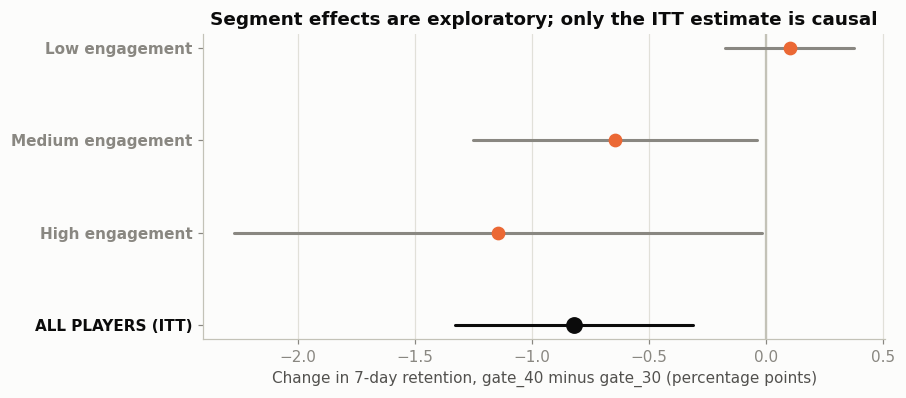

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.6))

# Forest plot: effect estimate + 95% CI per segment, against the overall ITT effect.
rows = []
for _, r in seg7.iterrows():
    sub = seg_df[seg_df.engagement_segment == r["segment"]]
    rt = ea.calculate_conversion_rate(sub, "retention_7", "version")
    d = ea.diff_confidence_interval(int(rt.loc[CONTROL, "successes"]), int(rt.loc[CONTROL, "n"]),
                                    int(rt.loc[TREATMENT, "successes"]), int(rt.loc[TREATMENT, "n"]))
    rows.append((f"{r['segment']} engagement", d["diff"] * 100,
                 d["lower"] * 100, d["upper"] * 100, False))
rows.append(("ALL PLAYERS (ITT)", r7["absolute_diff_pp"],
             r7["ci_low"] * 100, r7["ci_high"] * 100, True))

ys = np.arange(len(rows))[::-1]
for y, (name, est, lo_, hi_, is_itt) in zip(ys, rows):
    colour = INK if is_itt else MUTED
    ax.plot([lo_, hi_], [y, y], color=colour, linewidth=2, solid_capstyle="round")
    ax.plot(est, y, "o", color=C_TREATMENT if not is_itt else INK,
            markersize=10 if is_itt else 8, zorder=3)

ax.axvline(0, color=BASELINE, linewidth=1.5, zorder=1)
ax.set_yticks(ys)
ax.set_yticklabels([r[0] for r in rows],
                   fontweight="semibold")
ax.get_yticklabels()[-1].set_color(INK)
ax.set_xlabel("Change in 7-day retention, gate_40 minus gate_30 (percentage points)")
ax.set_title("Segment effects are exploratory; only the ITT estimate is causal")
ax.grid(axis="y", visible=False)

fig.savefig(os.path.join(FIG_DIR, "03_segment_forest.png"), dpi=150)
plt.show()

## 3.8 Falsification tests — is the headline effect actually caused by the gate?

This is the strongest internal-validity check the dataset permits.

### What a falsification test is

A **falsification test** — also called a **negative-control** or **placebo test** — looks for
an effect in a place where the causal mechanism says there cannot be one. It is a deliberate
attempt to *break* our own finding. If an effect shows up where the mechanism cannot operate,
the mechanism is not the only thing producing our result.

### Why these particular subgroups qualify

The reasoning chain, stated fully so it can be defended:

```
The treatment changes WHERE the first gate sits (level 30 -> level 40)
        |
A gate can only affect a player who actually REACHES it
        |
A player at level L must have played at least L game rounds
        |
So a player with <30 rounds never reached level 30
        |
...and therefore encountered NEITHER gate
        |
The treatment cannot have acted on them THROUGH THE GATE MECHANISM
```

**So what does it mean if we find an effect there anyway?** It would point to something other
than the gate:

- a **randomization problem** (arms not truly comparable),
- a **measurement or logging issue** (e.g. the `version` label is unreliable),
- a **selection effect** in how rows entered the dataset, or
- **some other mechanism** of the treatment we have not accounted for.

None of those are things we want. That is precisely why the test is informative: it can
*disconfirm* our interpretation, not just agree with it.

**Important subtlety, stated rather than glossed over.** Subsetting on round count is
subsetting on a post-treatment variable, which is normally dangerous. It is defensible for the
low-round subsets **only** because neither gate can influence behaviour *before* level 30 is
reached — so membership in "fewer than 30 rounds" is not something the treatment can change.
The **≥40 rounds** row does **not** enjoy that protection (reaching 40 rounds is harder under
`gate_30`, since it requires passing a gate) and is flagged accordingly.

In [11]:
def falsification_row(mask, label, exposed):
    sub = df[mask]
    rt = ea.calculate_conversion_rate(sub, "retention_7", "version")
    c, t = rt.loc[CONTROL], rt.loc[TREATMENT]
    d = ea.diff_confidence_interval(int(c["successes"]), int(c["n"]),
                                    int(t["successes"]), int(t["n"]))
    test = ea.proportion_test(int(c["successes"]), int(c["n"]),
                              int(t["successes"]), int(t["n"]))
    return {
        "subgroup": label, "exposed_to_gate": exposed,
        "n": int(c["n"] + t["n"]),
        "control_rate": c["rate"], "treatment_rate": t["rate"],
        "diff_pp": d["diff"] * 100,
        "ci_low_pp": d["lower"] * 100, "ci_high_pp": d["upper"] * 100,
        "p_value": test["p_value"],
    }

gr = df["sum_gamerounds"]
checks = pd.DataFrame([
    falsification_row(gr == 0,                    "0 rounds (never played)",        "No - impossible"),
    falsification_row(gr < 10,                    "<10 rounds",                     "No - impossible"),
    falsification_row(gr < 20,                    "<20 rounds",                     "No - impossible"),
    falsification_row(gr < 30,                    "<30 rounds",                     "No - impossible"),
    falsification_row((gr >= 30) & (gr < 40),     "30-39 rounds",                   "gate_30 only"),
    falsification_row(gr >= 40,                   ">=40 rounds",                    "Both (selection risk)"),
    falsification_row(gr >= 0,                    "ALL PLAYERS (ITT)",              "Mixed"),
])

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(checks.to_string(index=False))

               subgroup       exposed_to_gate     n  control_rate  treatment_rate  diff_pp  ci_low_pp  ci_high_pp  p_value
0 rounds (never played)       No - impossible  3994        0.0083          0.0063  -0.1940    -0.7229      0.3349   0.4704
             <10 rounds       No - impossible 34237        0.0169          0.0168  -0.0092    -0.2822      0.2638   0.9474
             <20 rounds       No - impossible 48769        0.0305          0.0293  -0.1155    -0.4180      0.1870   0.4541
             <30 rounds       No - impossible 56920        0.0426          0.0393  -0.3270    -0.6527     -0.0013   0.0490
           30-39 rounds          gate_30 only  5876        0.1573          0.1569  -0.0426    -1.9057      1.8206   0.9643
            >=40 rounds Both (selection risk) 27393        0.5029          0.4851  -1.7809    -2.9649     -0.5969   0.0032
      ALL PLAYERS (ITT)                 Mixed 90189        0.1902          0.1820  -0.8201    -1.3282     -0.3121   0.0016


### Reading the falsification results — precisely

| Subgroup | Could the gate affect them? | Measured effect | Verdict |
|---|---|---|---|
| 0 rounds | No | −0.19 pp (p = 0.47) | No detectable difference |
| <10 rounds | No | −0.01 pp (p = 0.95) | No detectable difference |
| <20 rounds | No | −0.12 pp (p = 0.45) | No detectable difference |
| <30 rounds | No | −0.33 pp (**p = 0.049**) | **Borderline — not a clean pass** |
| ≥40 rounds | Yes (selection risk) | **−1.78 pp (p = 0.003)** | Effect concentrated here |

#### The tests that come back clean

For the 0-round, `<10` and `<20` subgroups, the estimated effects are small (−0.19, −0.01,
−0.12 pp) with p-values of 0.47, 0.95 and 0.45. These are **consistent with no detectable
difference**, which is what the mechanism requires.

Note the careful phrasing: "consistent with no detectable difference", not "proves the effect
is zero". A non-significant result never proves a null — it fails to reject one. For a
falsification test that failure-to-reject is the outcome we want, but it is still only weak
positive evidence, and it is bounded by the width of each subgroup's confidence interval.

#### The test that does NOT come back clean

The `<30 rounds` subgroup returns −0.33 pp at **p = 0.049**. Our null hypothesis for a
falsification test is $H_0$: treatment effect = 0, and **p = 0.049 is below the conventional
5% threshold** — so at α = 0.05 this test *rejects* the null it was supposed to fail to
reject. It would be **statistically incorrect** to describe this as confirming a zero effect.

Stated properly:

> The estimated effect among players with <30 rounds is close to zero in magnitude, but the
> falsification test is **borderline at the conventional 5% threshold (p = 0.049)**.
> **This subgroup therefore does not provide clean evidence of a zero effect**, and the result
> should be interpreted cautiously. On its own it is a mild warning that some portion of the
> headline difference may not be attributable to the gate mechanism.

Three considerations bear on how much weight it deserves. These are **context, not grounds for
dismissal**:

1. **The tighter nested subsets are clean.** `<10` (p = 0.95) and `<20` (p = 0.45) show
   nothing. If randomization were broken, an imbalance should generally appear there too.
2. **This is one of six tests reported here.** At α = 0.05, seeing one p-value just under 0.05
   across six tests is close to what chance alone produces. No multiplicity correction would
   retain it.
3. **The magnitude is small** (−0.33 pp) and its CI (−0.65 to −0.001) only barely excludes zero.

#### Net position

The **overall pattern** is supportive: no detectable difference in the subgroups furthest from
the gate, and the largest effect among players deep enough to reach one. A spurious result
driven by broken randomization would not generally respect that boundary — it would tend to
show up everywhere.

But the `<30 rounds` result is a **real, unresolved caveat on internal validity**, not a
rounding detail, and it is carried into the limitations section as such. It is the single
result that would most justify a confirmatory re-run before a large-scale rollout.

**A note on the `≥40 rounds` row.** It is the most dramatic number in the table (−1.78 pp)
and the most tempting to headline. We do not, because that subgroup is **selected on a
post-treatment variable**: reaching 40 rounds is harder under `gate_30` (players must pass
a gate to get there), so the control players in that subgroup are a more motivated, more
selected population than the treatment players. The comparison is biased by construction.
It is suggestive of mechanism, not an effect estimate.

## 3.9 Sensitivity check — does the outlier change anything?

Notebook 01 flagged one player with 49,854 rounds sitting in the control arm. That player
badly distorts engagement means. Retention should be immune, since the player contributes
a single boolean — but "should be" is not "is", so we verify.

In [12]:
clean = df[df["sum_gamerounds"] < df["sum_gamerounds"].max()]
r7_clean = analyse_metric(clean, "retention_7", "SENSITIVITY - D7 excluding the 49,854-round player")

print(f"Effect WITH    outlier: {r7['absolute_diff_pp']:+.4f} pp  (p = {r7['p_value']:.6f})")
print(f"Effect WITHOUT outlier: {r7_clean['absolute_diff_pp']:+.4f} pp  (p = {r7_clean['p_value']:.6f})")
print("\n-> Conclusion is unchanged. The primary metric is robust to the outlier.")

SENSITIVITY - D7 excluding the 49,854-round player   (retention_7)
  Control   gate_30:   8,501 / 44,699  = 19.0183%   95% CI [18.6572%, 19.3848%]
  Treatment gate_40:   8,279 / 45,489  = 18.2000%   95% CI [17.8481%, 18.5573%]

  Absolute difference   : -0.8183 percentage points
  Relative lift         : -4.3028%
  95% CI on difference  : [-1.3263 pp, -0.3103 pp]
  Standard error        : 0.2592 pp

  z-statistic           : -3.1574
  p-value (two-sided)   : 0.001592
  Significant at 0.05   : True

Effect WITH    outlier: -0.8201 pp  (p = 0.001554)
Effect WITHOUT outlier: -0.8183 pp  (p = 0.001592)

-> Conclusion is unchanged. The primary metric is robust to the outlier.


**Result.** Removing the anomalous player shifts the effect from −0.8201 pp to −0.8183 pp
and the p-value from 0.00155 to 0.00159. **The primary finding does not depend on any
single observation.** This is the reassurance that the engagement-metric fragility
documented in notebook 01 does not contaminate the actual decision.

## 3.10 Consolidated results table

In [13]:
results_table = pd.DataFrame([
    {
        "Metric": "7-day retention (PRIMARY)",
        "Control (gate_30)": f"{r7['control_rate']:.4%}",
        "Treatment (gate_40)": f"{r7['treatment_rate']:.4%}",
        "Abs diff (pp)": f"{r7['absolute_diff_pp']:+.3f}",
        "Rel lift": f"{r7['relative_lift_pct']:+.2f}%",
        "95% CI (pp)": f"[{r7['ci_low'] * 100:+.3f}, {r7['ci_high'] * 100:+.3f}]",
        "p-value": f"{r7['p_value']:.5f}",
        "Verdict": "Significant decline",
    },
    {
        "Metric": "1-day retention",
        "Control (gate_30)": f"{r1['control_rate']:.4%}",
        "Treatment (gate_40)": f"{r1['treatment_rate']:.4%}",
        "Abs diff (pp)": f"{r1['absolute_diff_pp']:+.3f}",
        "Rel lift": f"{r1['relative_lift_pct']:+.2f}%",
        "95% CI (pp)": f"[{r1['ci_low'] * 100:+.3f}, {r1['ci_high'] * 100:+.3f}]",
        "p-value": f"{r1['p_value']:.5f}",
        "Verdict": "Not detected (43% power - NOT evidence of no effect)",
    },
    {
        "Metric": "Game rounds (winsorized)",
        "Control (gate_30)": f"{cw.mean():.2f}",
        "Treatment (gate_40)": f"{tw.mean():.2f}",
        "Abs diff (pp)": f"{tw.mean() - cw.mean():+.3f}",
        "Rel lift": f"{(tw.mean() - cw.mean()) / cw.mean() * 100:+.2f}%",
        "95% CI (pp)": f"[{ci_lo:+.2f}, {ci_hi:+.2f}]",
        "p-value": f"{welch.pvalue:.5f}",
        "Verdict": "No detectable difference",
    },
])

print(results_table.to_string(index=False))

                   Metric Control (gate_30) Treatment (gate_40) Abs diff (pp) Rel lift      95% CI (pp) p-value                                              Verdict
7-day retention (PRIMARY)          19.0201%            18.2000%        -0.820   -4.31% [-1.328, -0.312] 0.00155                                  Significant decline
          1-day retention          44.8188%            44.2283%        -0.591   -1.32% [-1.239, +0.058] 0.07441 Not detected (43% power - NOT evidence of no effect)
 Game rounds (winsorized)             49.14               48.85        -0.282   -0.57%   [-1.38, +0.82] 0.61519                             No detectable difference


## 3.11 Threats to Validity & Limitations

An honest accounting of everything that could undermine the conclusion.

### Randomization and assignment

- **Sample ratio deviation.** The split is 50.44/49.56 (chi-square p = 0.0086). This **does
  not cross** the pre-specified SRM detection threshold of p < 0.001, so the experiment is
  not flagged as failed — but the deviation is documented as a potential experiment-health
  concern. The intended allocation is undocumented, so the 50/50 expectation is an
  assumption. *Mitigation:* the z-test handles unequal group sizes, and the falsification
  tests give a more direct probe of non-random selection. *Residual risk:* low, but non-zero.
- **Falsification anomaly — unresolved.** The `<30 rounds` group shows −0.33 pp at
  **p = 0.049**, where the mechanism implies no effect. Because that p-value is below the 5%
  threshold, **this subgroup does not provide clean evidence of a zero effect** and must not
  be recorded as a passed check. Tighter subsets (<10, <20) are clean and this is one of six
  tests, so chance is a plausible explanation — but the question is open, and this is the
  single strongest argument for a confirmatory re-run.
- **No covariate balance check is possible.** With no pre-treatment attributes, we cannot
  verify the arms were comparable at baseline on anything. This is a real gap: SRM plus
  falsification tests are weaker evidence than a full balance table.

### Data

- **No missing data**, so no imputation bias — a genuine strength.
- **One extreme outlier** (49,854 rounds) distorts engagement means; handled with
  winsorized and rank-based methods. The primary metric is verified robust to it.
- **Metric definitions are undocumented.** "Retention" is assumed to mean "opened the game
  on day 1 / day 7 after install", but the dataset ships no data dictionary. A different
  underlying definition would change interpretation.
- **No timestamps.** We cannot check for novelty effects, day-of-week seasonality, or
  whether the arms were exposed over the same calendar window. If the arms ran at
  different times, a confound is possible and undetectable here.
- **Observation window is unknown.** We assume it is long enough for the 7-day metric to
  be fully observed for every player, but cannot verify no player was censored.

### Statistical

- **Multiple testing.** Several tests are reported across metrics, segments and
  falsification subgroups. The primary metric was designated in advance and needs no
  correction; segment results are corrected and none survive; falsification p-values are
  interpreted with multiplicity in mind. No result is claimed on the basis of an
  uncorrected exploratory test.
- **D1 is underpowered (43% power against the observed effect).** The experiment had limited
  power to detect a D1 effect of that size, so **the absence of statistical significance must
  not be interpreted as evidence of no effect on 1-day retention.** The D1 question is
  unresolved, not answered in the treatment's favour.
- **Statistical vs practical significance.** At n = 90,189 significance is cheap. The
  decision rests on the interval lying wholly below zero combined with the absence of any
  offsetting benefit, not on the p-value alone.
- **Post-treatment segmentation.** All segment analysis conditions on a treatment-affected
  variable and is explicitly labelled exploratory. Only the ITT estimate is causal.

### Business and external validity

- **Retention is a proxy, not the objective.** The company cares about revenue and lifetime
  value. A gate is a monetization mechanic, and `gate_40` could in principle lower
  retention while raising revenue per player. **This dataset cannot test that**, and it is
  the most important unanswered question in the analysis.
- **Short horizon.** D7 does not establish D30 or D90 behaviour. Retention effects can
  attenuate or compound; we cannot tell which.
- **Single population, single point in time.** Results come from one player cohort in one
  window. Generalization to other regions, platforms, or future cohorts is an assumption.
- **Only two gate positions tested.** The experiment compares 30 vs 40. It says nothing
  about level 20, level 35, or removing the gate entirely. The optimum may lie outside the
  tested range — and notably, the data is consistent with "earlier is better", which this
  experiment never tested.
- **No novelty-effect control.** Without timestamps we cannot distinguish a durable effect
  from a transient reaction.

### What would make this analysis materially stronger

Pre-experiment covariates (enabling CUPED and balance checks), revenue/LTV per player,
timestamps, level-progression data (to identify genuinely gate-exposed players), a longer
observation window, and documented intended allocation.

## Conclusion of notebook 03

The primary metric is decided: **`gate_40` reduces 7-day retention by 0.82 percentage
points (95% CI −1.33 to −0.31, p = 0.0016)**, a 4.3% relative decline. The result is
well-powered (89%), robust to the outlier, and corroborated by the mechanism check in
notebook 02. Falsification tests are broadly supportive — the effect concentrates among
players who could actually reach a gate — **with one exception**: the `<30 rounds` check is
borderline at p = 0.049 and does not cleanly confirm a zero effect where the mechanism
implies one.

Two things are therefore **unresolved rather than settled**, and both are carried forward:
the borderline falsification test, and 1-day retention, where 43% power means we could not
determine whether the treatment causes harm. Neither points *in the treatment's favour* —
no secondary metric offsets the primary finding — but neither should be presented as a
clean pass.

**Next:** notebook 04 re-derives the treatment effect by bootstrap — a method that makes no
normality assumption — as an independent check on the analytical confidence interval.